In [1]:
# Run surrogate predictions

from gpPredict import *
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import os

import pickle

from get_bw_params import *
from run_column_model import *

'''
The function below is loaded from get_bw_params.py
# Load pickle file with logistic regression
with open('log_reg_model.pkl', 'rb') as f:
    failure_mode_selection = pickle.load(f)
    # First parameter is the aspect ratio
    # Second parameter is Vp/Vs

    # Codes:
    # 0 = Flexure
    # 1 = Shear

# Use latex for plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
# ndParams = ['ar', 'lrr', 'srr', 'alr', 'sdr', 'smr']
# ndParams = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1]

def get_BW_params(ndParams):

    # Define the failure mode using the logistic regression model
    failure_mode = failure_mode_selection.predict(np.array([[ndParams[0], ndParams[5]]]))[0]

    # Define the surrogate_file and input_json based on the failure mode
    if failure_mode == 0:
        print('Flexure failure mode')
        surrogate_file = os.path.join('gpModelFlexure', 'SimGpModel.json')
        input_json = os.path.join('gpModelFlexure', 'scInput.json')
    else:
        print('Shear failure mode')
        surrogate_file = os.path.join('gpModelShear', 'SimGpModel.json')
        input_json = os.path.join('gpModelShear', 'scInput.json')

    params_list = [
        ["RV_column1", ndParams[0]],
        ["RV_column2", ndParams[1]],
        ["RV_column3", ndParams[2]],
        ["RV_column4", ndParams[3]],
        ["RV_column5", ndParams[4]],
        ["RV_column6", ndParams[5]]
    ]

    output = main(params_list, [], surrogate_file, 'dummyout.out', input_json)
    
    # bw model parameters are the all the output parameters except the last one
    bw_model_params = (output[0][:-1].T).tolist()

    # min error is the last output parameter
    min_error = float(output[0][-1])
    
    return bw_model_params, min_error'''


'\nThe function below is loaded from get_bw_params.py\n# Load pickle file with logistic regression\nwith open(\'log_reg_model.pkl\', \'rb\') as f:\n    failure_mode_selection = pickle.load(f)\n    # First parameter is the aspect ratio\n    # Second parameter is Vp/Vs\n\n    # Codes:\n    # 0 = Flexure\n    # 1 = Shear\n\n# Use latex for plots\nplt.rc(\'text\', usetex=True)\nplt.rc(\'font\', family=\'serif\')\n# ndParams = [\'ar\', \'lrr\', \'srr\', \'alr\', \'sdr\', \'smr\']\n# ndParams = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1]\n\ndef get_BW_params(ndParams):\n\n    # Define the failure mode using the logistic regression model\n    failure_mode = failure_mode_selection.predict(np.array([[ndParams[0], ndParams[5]]]))[0]\n\n    # Define the surrogate_file and input_json based on the failure mode\n    if failure_mode == 0:\n        print(\'Flexure failure mode\')\n        surrogate_file = os.path.join(\'gpModelFlexure\', \'SimGpModel.json\')\n        input_json = os.path.join(\'gpModelFlexure\', \

Finished... Run Time =  1.1175951957702637 sec
Finished... Run Time =  5.115727186203003 sec
Calibration Error:  0.1470580200103304  --- std:  0.10330895228040592
Surrogate Error:  6.62772792091256  --- std:  5.612619432013595
Surrogate-Calibration Error:  6.536434777129135  --- std:  5.507937383728182
No Model Error:  0.2430992761104721
1 - Model Error:  0.7569007238895279


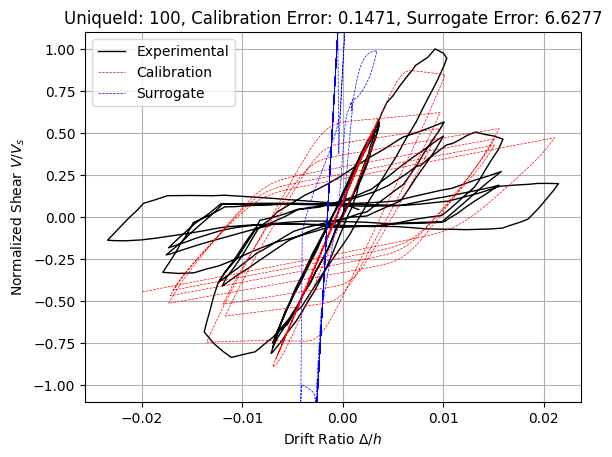

In [4]:
# Open calibration_info.csv
calibration_info = pd.read_csv('calibration_info.csv')

# Open data_all.csv file
data_all = pd.read_csv('data_all.csv')

# Create a new dataframe to store the error metrics
error_metrics = pd.DataFrame(columns=['UniqueId', 'err_cal_exp', 'err_surr_exp', 'err_surr_cal', 'ar', 'lrr', 'srr', 'alr', 'sdr', 'smr'])


# Iterate over all rows in calibration_info
for ii in [149]:#:range(len(calibration_info)):
    # Get the UniqueId

    # *Task 1) Need to find whether it's in test or training dataset...
    UniqueId = calibration_info['UniqueId'].iloc[ii]

    # Find UniqueId in data_all
    row = data_all[data_all['UniqueId'] == UniqueId]

    # For this row, get the calibrated bw model parameters
    calParams = calibration_info[['gamma', 'kappa', 'eta1', 'sig', 'lam', 'mup', 'sigp', 'rsmax', 'alpha', 'alpha1', 'alpha2', 'betam1', 'n', 'kappa_k']].iloc[ii].values

    # Now, from data_all, get the nondimensional parameters
    ndParams = row[['ar', 'lrr', 'srr', 'alr', 'sdr', 'smr']].values[0]

    # Get surrogate-predicted bw model parameters
    predParams, predErr, failureMode = get_BW_params(ndParams, mode='interp')

    # Get the test_XXX.json file from test_data folder where XXX is the UniqueId
    with open('test_data/test_' + str(UniqueId).zfill(3) + '.json') as f:
        test_data = json.load(f)

    # Run the column model with the calParams
    calResults = run_model(test_data, calParams, do_plots=False)

    # Run the column model with the predParams
    surrResults = run_model(test_data, predParams, do_plots=False)

    print('Calibration Error: ', calResults['err_data']['mean_err'], ' --- std: ', calResults['err_data']['std_err'])
    print('Surrogate Error: ', surrResults['err_data']['mean_err'], ' --- std: ', surrResults['err_data']['std_err'])

    # Calculate difference between surrogate and calibration
    err_surr_cal = np.mean(np.abs(np.array(surrResults['sim_data']['nforce']) - np.array(calResults['sim_data']['nforce'])))
    std_surr_cal = np.std(np.abs(np.array(surrResults['sim_data']['nforce']) - np.array(calResults['sim_data']['nforce'])))

    print('Surrogate-Calibration Error: ', err_surr_cal, ' --- std: ', std_surr_cal)
    print('No Model Error: ', surrResults['err_data']['no_model_err'])
    print('1 - Model Error: ', surrResults['err_data']['one_model_err'])

    plt.figure()
    # Plot experimental data
    plt.plot(calResults['exp_data']['drift'], calResults['exp_data']['nforce'], label='Experimental', color='black', linewidth=1.0)
    # Plot from calResults drift vs normalized force
    plt.plot(calResults['sim_data']['drift'], calResults['sim_data']['nforce'], label='Calibration', color='red', linewidth=0.5, linestyle='--')
    # Plot from surrResults displacement vs normalized force
    plt.plot(surrResults['sim_data']['drift'], surrResults['sim_data']['nforce'], label='Surrogate', color='blue', linewidth=0.5, linestyle='--')
    plt.xlabel('Drift Ratio $\Delta/h$')
    plt.ylabel('Normalized Shear $V/V_s$')
    plt.legend()
    plt.title('UniqueId: ' + str(UniqueId) + ', Calibration Error: ' + 
              format(calResults['err_data']['mean_err'], '.4f') + 
              ', Surrogate Error: ' + format(surrResults['err_data']['mean_err'], '.4f'))
    # Set ylim
    plt.ylim([-1.1, 1.1])
    # Add grid
    plt.grid()
    plt.show()

    # Append to error_metrics dataframe
    error_metrics = error_metrics.append(
        {
            'UniqueId': UniqueId, 
            'err_cal_exp': calResults['err_data']['mean_err'],
            'err_surr_exp': surrResults['err_data']['mean_err'],
            'no_model_err': surrResults['err_data']['no_model_err'],
            'one_model_err': surrResults['err_data']['one_model_err'],
            'err_surr_cal': err_surr_cal,
            'ar': ndParams[0],
            'lrr': ndParams[1],
            'srr': ndParams[2],
            'alr': ndParams[3],
            'sdr': ndParams[4],
            'smr': ndParams[5],
            'ColumnType': row['Type'].values[0],
            'FailureMode': row['FailureType'].values[0]
        }, ignore_index=True)

# Save error_metrics to a csv file
error_metrics.to_csv('error_metrics_interp.csv', index=False)
